In [1]:
import numpy as np
import sys
import muram as mio  
import matplotlib.pyplot as plt

In [2]:
# For the SSD data with ch and corona - you can use this path:
pathsource = '/dat/milic/MURaM_enhanced_network/'
#pathsource =  '/dat/milic/MURAM_SSD_ch_co_25x25x25Mm/'
#pathsource = '/dat/milic/'
#pathsource = '/dat/milic/MURaM_SSD_che/'

#pathsource = '/dat/milic/MURaM_400G_plage_pore/'

#Should not need this, but check the structure of the folder
path3D = pathsource# + '3D/'
path2D = pathsource# + '2D/'

In [3]:
# For the other SSD data, with higher resolution and photospher only, use this path:
#pathsource = '/dat/milic/'
#path3D = pathsource + '3D/3D_full_subdomain/' # Sorry I was rearranging something there
#path2D = pathsource + '2D/'

In [4]:
# IF you used the first one, it's FULL snaps - so use MuramSnap
#cube = mio.MuramSnap(path3D, 399000)
cube = mio.MuramSnap(path3D, 499000)
# But for the other one, they are so called SUBSNAPS - so you use MuramSubSnap
#snapno = 499000
#cube = mio.MuramSubSnap(path3D, snapno)
#cube = mio.MuramSnap(path3D, snapno)


In [5]:
#pathsource_ssd = '/dat/milic/MURaM_SSD_EN'
#snapno_ssd = 399000
#cube_ssd = mio.MuramSnap(pathsource_ssd, snapno_ssd)

In [6]:
cube.available

['rho',
 'vx',
 'vy',
 'vz',
 'eint',
 'Bx',
 'By',
 'Bz',
 'sflx',
 'Temp',
 'Pres',
 'ne',
 'tau']

In [7]:
cube.Temp.shape

(800, 1024, 1024)

In [8]:
T_mean = np.mean(cube.Temp, axis=(1,2))

In [9]:
tau_mean = np.mean(cube.tau, axis=(1,2))

In [10]:
# Find me the index closest to tau = 1
tau_diff = np.abs(tau_mean - 1)
tau_index = np.argmin(tau_diff)
print(f"Index closest to tau=1: {tau_index}, tau value at this index: {tau_mean[tau_index]}")

Index closest to tau=1: 49, tau value at this index: 1.3069764375686646


In [11]:
z_axis = (np.arange(cube.Temp.shape[0]) - 49)*20.0  # Assuming the first dimension is z

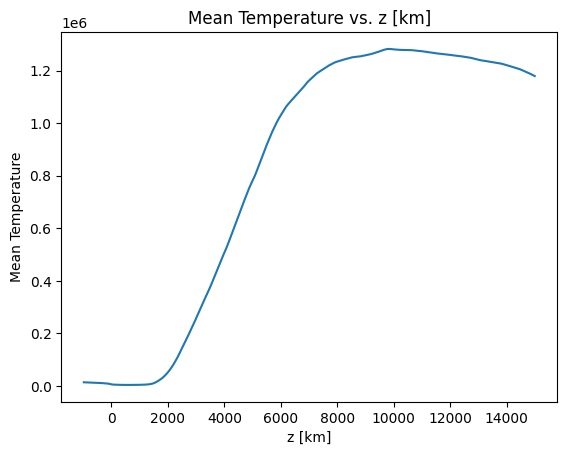

In [12]:
plt.plot(z_axis, T_mean)
plt.xlabel('z [km]')
plt.ylabel('Mean Temperature')
plt.title('Mean Temperature vs. z [km]')
plt.show()

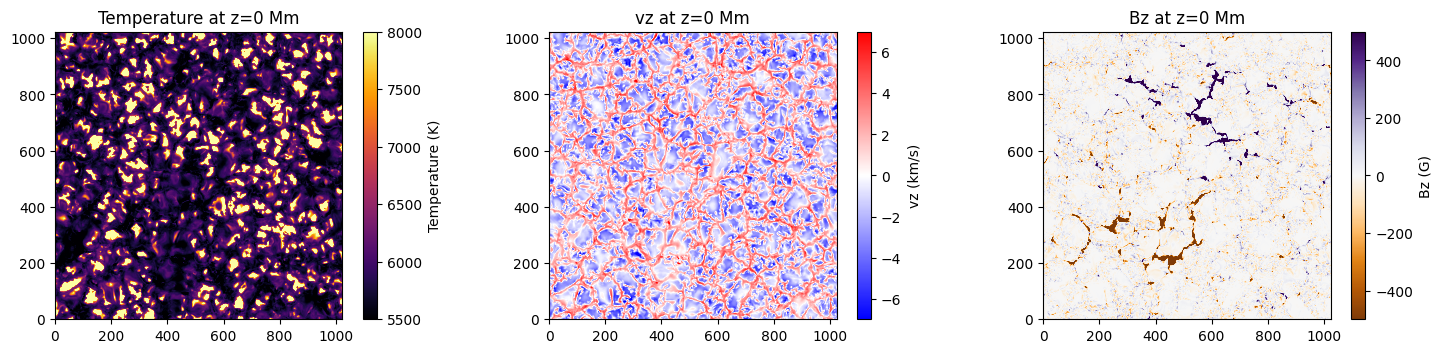

In [13]:
# Let's look at the Bx and By components of the magnetic field:
plt.figure(figsize=(15, 3.6))
plt.subplot(1, 3, 1)
plt.imshow(cube.Temp[tau_index,:, :].T, origin='lower', cmap='inferno',vmin=5500,vmax=8000)
plt.colorbar(label='Temperature (K)')
plt.title('Temperature at z=0 Mm')
plt.subplot(1, 3, 2)
plt.imshow(cube.vx[tau_index,:, :].T/-1E5, origin='lower', cmap='bwr',vmin=-7,vmax=7)
plt.colorbar(label='vz (km/s)')
plt.title('vz at z=0 Mm')
plt.subplot(1, 3, 3)
plt.imshow(cube.Bx[tau_index,:, :].T*np.sqrt(4.0*np.pi), origin='lower', cmap='PuOr',vmin=-500,vmax=500)
plt.colorbar(label='Bz (G)')
plt.title('Bz at z=0 Mm')
plt.tight_layout()
plt.show()

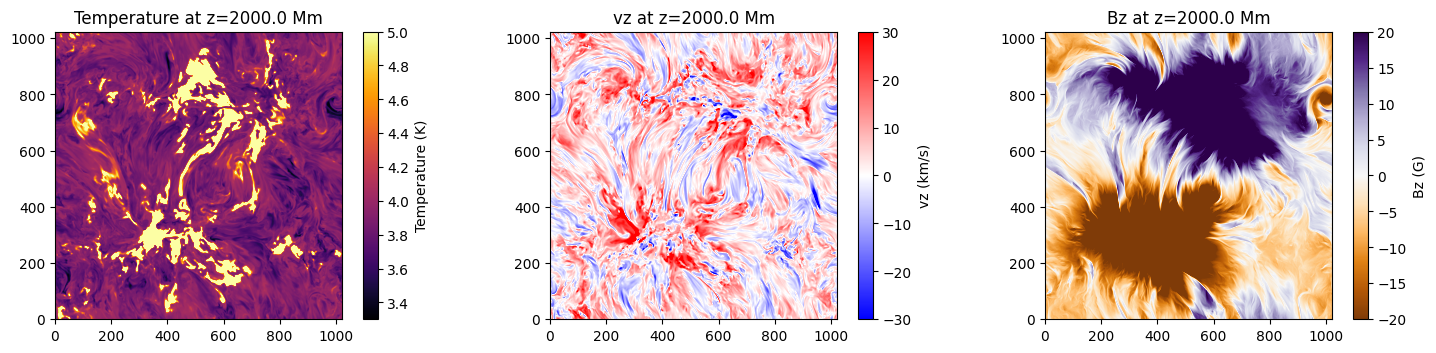

In [14]:
index_ch = tau_index + (2000 // 20)
# Let's look at the Bx and By components of the magnetic field:
plt.figure(figsize=(15, 3.6))
plt.subplot(1, 3, 1)
plt.imshow(np.log10(cube.Temp[index_ch,:, :]).T, origin='lower', cmap='inferno',vmin=3.3,vmax=5)
plt.colorbar(label='Temperature (K)')
plt.title(f'Temperature at z={z_axis[index_ch]} Mm')
plt.subplot(1, 3, 2)
plt.imshow(cube.vx[index_ch,:, :].T/-1E5, origin='lower', cmap='bwr',vmin=-30,vmax=30)
plt.colorbar(label='vz (km/s)')
plt.title(f'vz at z={z_axis[index_ch]} Mm')
plt.subplot(1, 3, 3)
plt.imshow(cube.Bx[index_ch,:, :].T*np.sqrt(4.0*np.pi), origin='lower', cmap='PuOr',vmin=-20,vmax=20)
plt.colorbar(label='Bz (G)')
plt.title(f'Bz at z={z_axis[index_ch]} Mm')
plt.tight_layout()
plt.show()

In [15]:
x_axis = (np.arange(cube.Temp.shape[1]))*24.0  # Assuming the second dimension is x

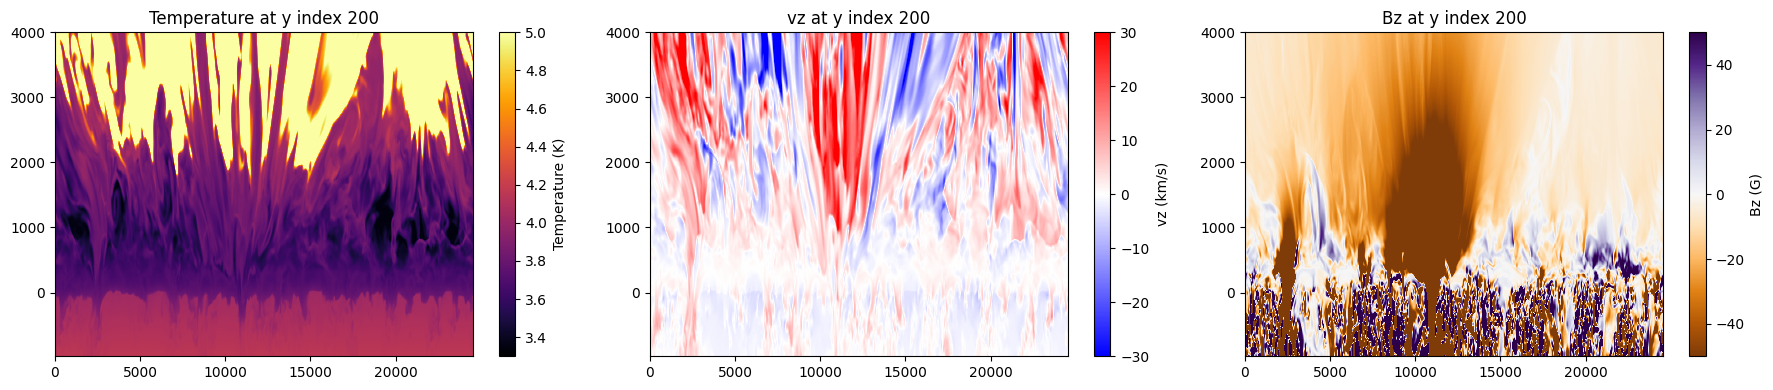

In [16]:
# Let's look at some vertical cuts through the cube at a specific x or y indices:
j = 200
plt.figure(figsize=[18, 4])
plt.subplot(1, 3, 1)
plt.imshow(np.log10(cube.Temp[:tau_index+200,:,j]), origin='lower', cmap='inferno',vmin=3.3,vmax=5, aspect='auto', extent = [0, x_axis[-1], z_axis[0], z_axis[tau_index+200]])
plt.colorbar(label='Temperature (K)')
plt.title(f'Temperature at y index {j}')
plt.subplot(1, 3, 2)
plt.imshow(cube.vx[:tau_index+200,:,j]/-1E5, origin='lower', cmap='bwr',vmin=-30,vmax=30, aspect='auto', extent = [0, x_axis[-1], z_axis[0], z_axis[tau_index+200]])
plt.colorbar(label='vz (km/s)')
plt.title(f'vz at y index {j}')
plt.subplot(1, 3, 3)
plt.imshow(cube.Bx[:tau_index+200,:,j]*np.sqrt(4.0*np.pi), origin='lower', cmap='PuOr',vmin=-50,vmax=50, aspect='auto', extent = [0, x_axis[-1], z_axis[0], z_axis[tau_index+200]])
plt.colorbar(label='Bz (G)')
plt.title(f'Bz at y index {j}')
plt.tight_layout()

In [17]:
# Let's calculate plasma beta and plot it as a vertical cut at the same y index:
# Plasma beta = (8 * pi * P) / B^2
j = 200
# Calculate the B in this slice 
B_slice = np.sqrt(cube.Bx[:,:,j]**2 + cube.By[:,:,j]**2 + cube.Bz[:,:,j]**2) * np.sqrt(4.0*np.pi)  # Convert to Gauss
p_slice = cube.Pres[:, :, j]  # Pressure slice at the same y index
beta_slice = (8 * np.pi * p_slice) / (B_slice**2 + 1e-10)  # Add a small number to avoid division by zero

In [18]:
Pgas = cube.Pres[:, :, :]
B_total = np.sqrt(cube.Bx[:,:,:]**2 + cube.By[:,:,:]**2 + cube.Bz[:,:,:]**2) * np.sqrt(4.0*np.pi)  # Convert to Gauss

# For the beta slice we want to calculate where beta is closest to 1 and find the average of that along x
# 
# Full beta:
beta_full = (8 * np.pi * Pgas) / (B_total**2 + 1e-10)  # Add a small number to avoid division by zero
beta_1_indices_map = np.zeros([beta_full.shape[1], beta_full.shape[2]], dtype=int)
for i in range(beta_full.shape[1]):
    for j in range(beta_full.shape[2]):
        beta_column = beta_full[:, i, j]
        closest_index = np.argmin(np.abs(beta_column[:tau_index+200] - 1))
        beta_1_indices_map[i, j] = closest_index

beta_1_mean = np.mean(beta_1_indices_map)
print(f"Average z index where plasma beta is closest to 1: {beta_1_mean}, corresponding z value: {z_axis[int(beta_1_mean)]} Mm")

Average z index where plasma beta is closest to 1: 93.08988952636719, corresponding z value: 880.0 Mm


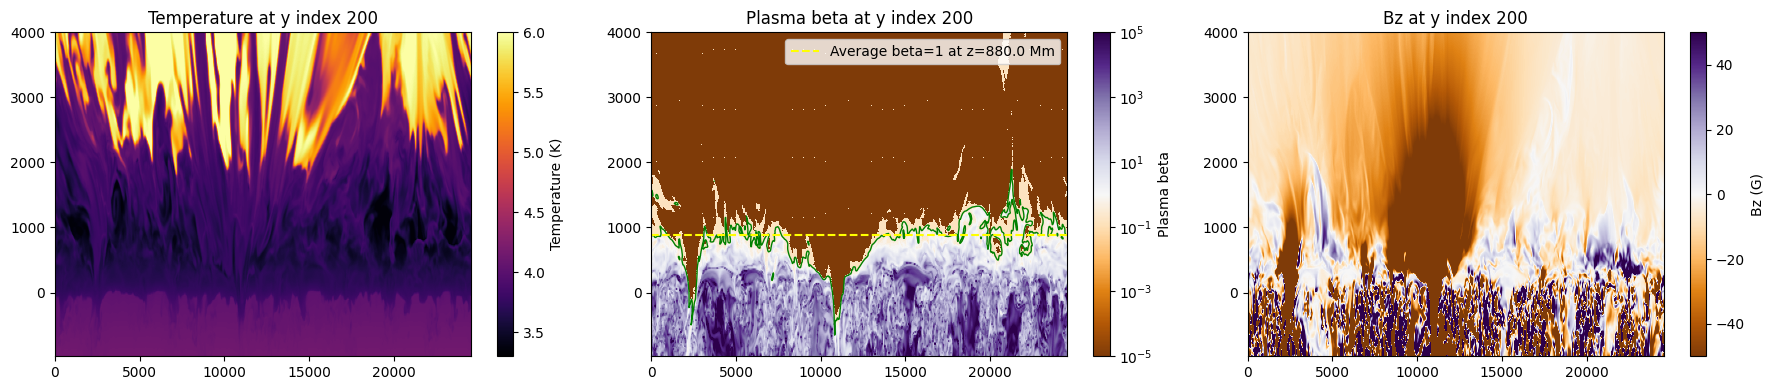

In [50]:
# Let's look at some vertical cuts through the cube at a specific x or y indices:
j = 200
plt.figure(figsize=[18, 4])
plt.subplot(1, 3, 1)
plt.imshow(np.log10(cube.Temp[:tau_index+200,:,j]), origin='lower', cmap='inferno',vmin=3.3,vmax=6.0, aspect='auto', extent = [0, x_axis[-1], z_axis[0], z_axis[tau_index+200]])
plt.colorbar(label='Temperature (K)')
plt.title(f'Temperature at y index {j}')
plt.subplot(1, 3, 2)
plt.imshow(beta_slice[:tau_index+200,:], origin='lower', cmap='PuOr',vmin=1e-5,vmax=1e5, norm='log', aspect='auto', extent = [0, x_axis[-1], z_axis[0], z_axis[tau_index+200]])
plt.colorbar(label='Plasma beta')
# Let's add a contour where plasma beta = 1
plt.contour(beta_slice[:tau_index+200,:], levels=[1], colors='green', linewidths=1, extent = [0, x_axis[-1], z_axis[0], z_axis[tau_index+200]])
# Add the mean line where plasma beta is closest to 1
plt.axhline(y=z_axis[int(beta_1_mean)], color='yellow', linestyle='--', label=f'Average beta=1 at z={z_axis[int(beta_1_mean)]} Mm')
plt.legend()    
plt.title(f'Plasma beta at y index {j}')
plt.subplot(1, 3, 3)
plt.imshow(cube.Bx[:tau_index+200,:,j]*np.sqrt(4.0*np.pi), origin='lower', cmap='PuOr',vmin=-50,vmax=50, aspect='auto', extent = [0, x_axis[-1], z_axis[0], z_axis[tau_index+200]])
plt.colorbar(label='Bz (G)')
plt.title(f'Bz at y index {j}')
plt.tight_layout()
plt.savefig("figs_O_Steiner/vertical_cuts_y_index_200.png",bbox_inches='tight')

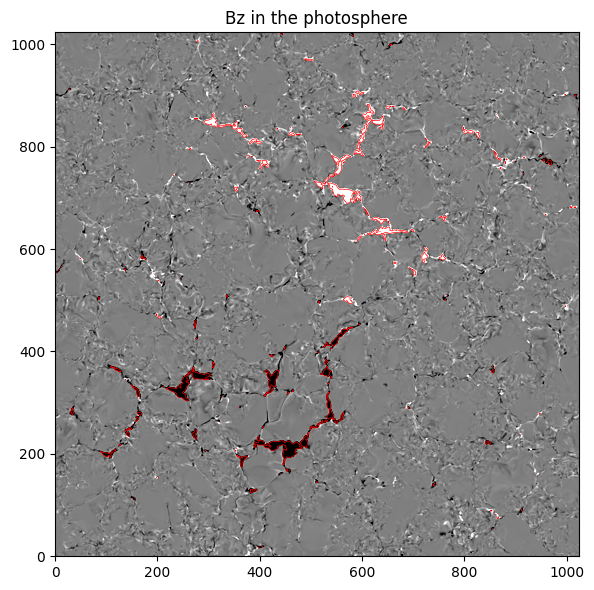

In [20]:
# We want to identify a individual flux tube in the photosphere: 
plt.figure(figsize=[10, 6])
plt.imshow(cube.Bx[tau_index,:, :].T*np.sqrt(4.0*np.pi), origin='lower', cmap='gray',vmin=-500,vmax=500)
# Add a contour to highlight the flux tube where the magnetic field is stronger than 500G
plt.contour(np.abs(cube.Bx[tau_index,:, :].T*np.sqrt(4.0*np.pi)), levels=[1000], colors='red', linewidths=0.5)
#plt.colorbar(label='Bx (G)')
plt.title('Bz in the photosphere')
plt.tight_layout()
plt.savefig("figs_O_Steiner/photosphere_flux_tube_mask.png",bbox_inches='tight')

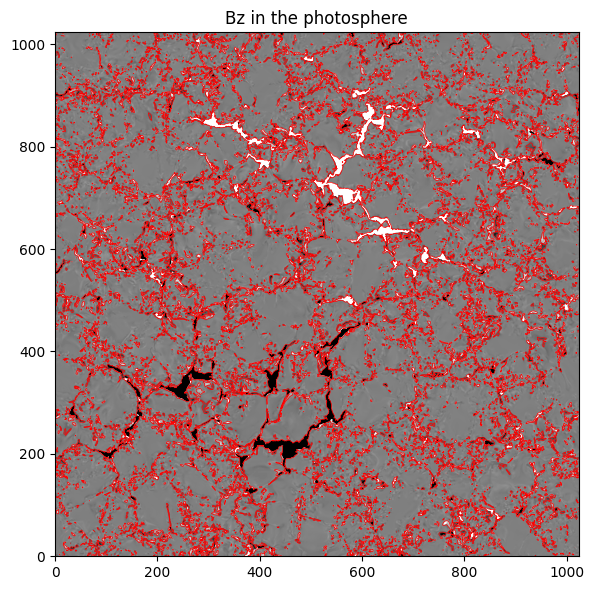

In [21]:
# We want to identify a individual flux tube in the photosphere: 
plt.figure(figsize=[10, 6])
plt.imshow(cube.Bx[tau_index,:, :].T*np.sqrt(4.0*np.pi), origin='lower', cmap='gray',vmin=-500,vmax=500)
# Add a contour to highlight the flux tube where the magnetic field is stronger than 500G
plt.contour(np.abs(cube.Bx[tau_index,:, :].T*np.sqrt(4.0*np.pi)), levels=[100], colors='red', linewidths=0.5)
#plt.colorbar(label='Bx (G)')
plt.title('Bz in the photosphere')
plt.tight_layout()
plt.savefig("photosphere_flux_tube.png",bbox_inches='tight')

In [22]:
T = cube.Temp[:,:,:].transpose(1,2,0)
Bz = cube.Bx.transpose(1,2,0) * np.sqrt(4.0*np.pi)
tau = cube.tau.transpose(1,2,0)
Pgas = cube.Pres.transpose(1,2,0)

In [23]:
# Now we create two masks, one strong (>1000G), and one weak (<100G) and we create the average atmospheres and plot theit T(tau) heights:
strong_mask = np.abs(Bz[:,:,tau_index]) > 1000
weak_mask = np.abs(Bz[:,:,tau_index]) < 100

mean_strong_atmosphere = T[strong_mask].mean(axis=(0))
mean_weak_atmosphere = T[weak_mask].mean(axis=(0))

In [24]:
tau_mean_strong = tau[strong_mask].mean(axis=(0))
tau_mean_weak = tau[weak_mask].mean(axis=(0))

In [25]:
Pg_mean_strong = Pgas[strong_mask].mean(axis=0)
Pg_mean_weak = Pgas[weak_mask].mean(axis=0)

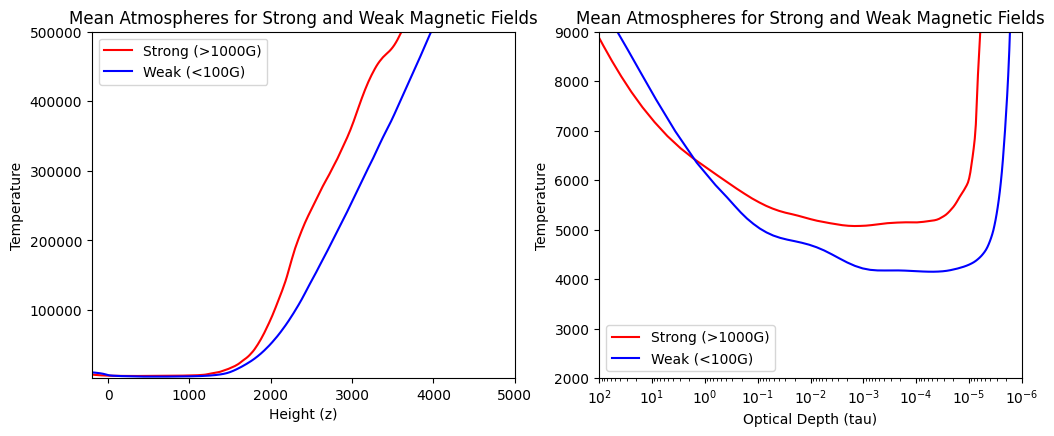

In [51]:
plt.figure(figsize=[12,4.5])
plt.subplot(1,2,1)
plt.plot(z_axis, mean_strong_atmosphere, color='red')
plt.plot(z_axis, mean_weak_atmosphere, color='blue')
plt.xlim([-200,5000])
plt.ylim([2000, 500000])
plt.xlabel('Height (z)')
plt.ylabel('Temperature')
plt.title('Mean Atmospheres for Strong and Weak Magnetic Fields')
plt.legend(['Strong (>1000G)', 'Weak (<100G)'])

plt.subplot(1,2,2)
plt.semilogx(tau_mean_strong, mean_strong_atmosphere, color='red')
plt.semilogx(tau_mean_weak, mean_weak_atmosphere, color='blue')
plt.xlim([1e2, 1e-6])
plt.ylim([2000, 9000])
plt.xlabel('Optical Depth (tau)')
plt.ylabel('Temperature')
plt.title('Mean Atmospheres for Strong and Weak Magnetic Fields')
plt.legend(['Strong (>1000G)', 'Weak (<100G)'])
#plt.savefig('figs_O_Steiner/mean_atmospheres_unshifted.png', bbox_inches='tight')



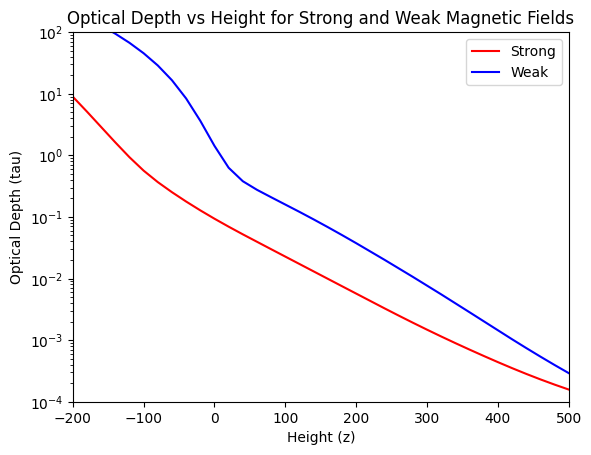

In [27]:
plt.semilogy(z_axis, tau_mean_strong, label='Strong', color='red')
plt.semilogy(z_axis, tau_mean_weak, label='Weak', color='blue')
plt.xlim([-200,500])
plt.ylim([1e-4, 1e2])
plt.xlabel('Height (z)')
plt.ylabel('Optical Depth (tau)')
plt.title('Optical Depth vs Height for Strong and Weak Magnetic Fields')
plt.legend()
plt.title('Optical Depth vs Height for Strong and Weak Magnetic Fields')
plt.legend()
plt.savefig('figs_O_Steiner/optical_depth_vs_height.png', bbox_inches='tight')

In [28]:
# Now we calculate "Wilson depression" of the flux tubes:
wilson_depression_strong = z_axis[np.argmin(np.abs(tau_mean_strong - 1))]
wilson_depression_weak = z_axis[np.argmin(np.abs(tau_mean_weak - 1))]
z_wd = wilson_depression_strong - wilson_depression_weak
print("Wilson depression (strong):", wilson_depression_strong)
print("Wilson depression (weak):", wilson_depression_weak)
print("Difference in Wilson depression:", z_wd)


Wilson depression (strong): -120.0
Wilson depression (weak): 20.0
Difference in Wilson depression: -140.0


In [36]:
# Load the three model atmospheres that Oskar sent 
atm_and = np.loadtxt("figs_O_Steiner/anderson.d", skiprows=1, usecols=(1,2), max_rows=119)
atm_cp = np.loadtxt("figs_O_Steiner/cprime.d", skiprows=1, usecols=(1,2), max_rows=68)
atm_fluxt = np.loadtxt("figs_O_Steiner/fluxt.d", skiprows=1, usecols=(1,2), max_rows=71)


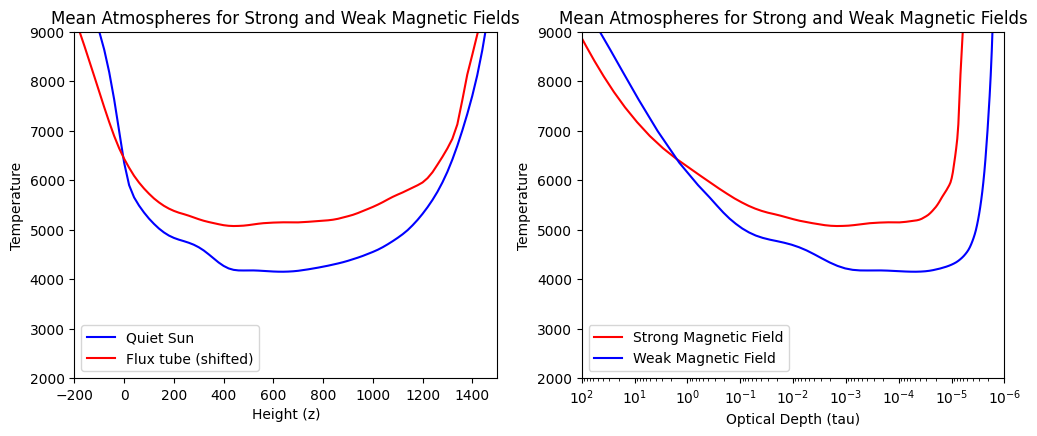

In [45]:
plt.figure(figsize=[12,4.5])
plt.subplot(1,2,1)
#plt.plot(z_axis, mean_strong_atmosphere, color='red', linestyle='--', label = 'Flux tube')
plt.plot(z_axis, mean_weak_atmosphere, color='blue', label = 'Quiet Sun')
plt.plot(z_axis-z_wd, mean_strong_atmosphere, color='red', label = 'Flux tube (shifted)')
plt.xlim([-200,1500])
plt.ylim([2000, 9000])
plt.xlabel('Height (z)')
plt.ylabel('Temperature')
plt.title('Mean Atmospheres for Strong and Weak Magnetic Fields')
plt.legend()

plt.subplot(1,2,2)
plt.semilogx(tau_mean_strong, mean_strong_atmosphere, color='red', label='Strong Magnetic Field')
plt.semilogx(tau_mean_weak, mean_weak_atmosphere, color='blue', label='Weak Magnetic Field')
plt.xlim([1e2, 1e-6])
plt.ylim([2000, 9000])
plt.xlabel('Optical Depth (tau)')
plt.ylabel('Temperature')
plt.title('Mean Atmospheres for Strong and Weak Magnetic Fields')
plt.legend()
plt.savefig('figs_O_Steiner/mean_atmosphere_T_shifted.png', bbox_inches='tight')

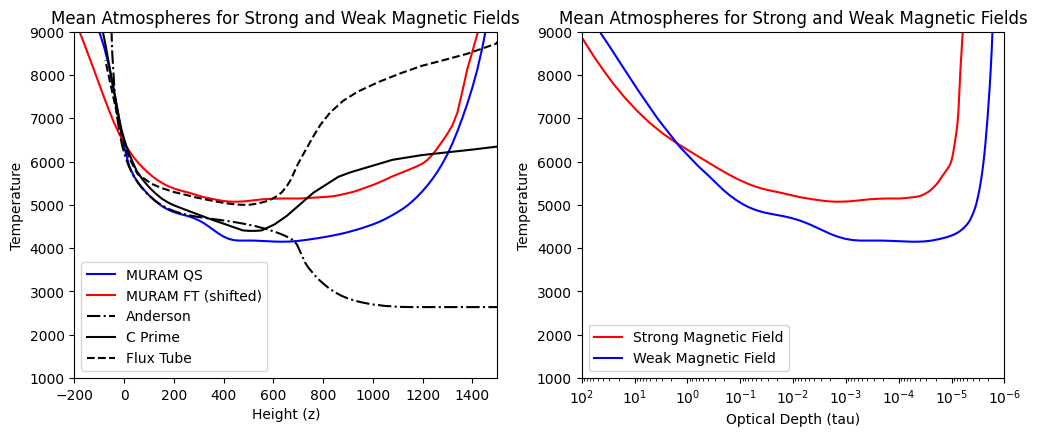

In [48]:
plt.figure(figsize=[12,4.5])
plt.subplot(1,2,1)
#plt.plot(z_axis, mean_strong_atmosphere, color='red', linestyle='--', label = 'Flux tube')
plt.plot(z_axis, mean_weak_atmosphere, color='blue', label = 'MURAM QS')
plt.plot(z_axis-z_wd, mean_strong_atmosphere, color='red', label = 'MURAM FT (shifted)')

plt.plot(atm_and[:,0]/1E5, atm_and[:,1], color='black', linestyle='-.', label='Anderson')
plt.plot(atm_cp[:,0]/1E5, atm_cp[:,1], color='black', label='C Prime')
plt.plot(atm_fluxt[:,0]/1E5, atm_fluxt[:,1], color='black', linestyle='--', label='Flux Tube')


plt.xlim([-200,1500])
plt.ylim([1000, 9000])
plt.xlabel('Height (z)')
plt.ylabel('Temperature')
plt.title('Mean Atmospheres for Strong and Weak Magnetic Fields')
plt.legend(loc='lower left')

plt.subplot(1,2,2)
plt.semilogx(tau_mean_strong, mean_strong_atmosphere, color='red', label='Strong Magnetic Field')
plt.semilogx(tau_mean_weak, mean_weak_atmosphere, color='blue', label='Weak Magnetic Field')
plt.xlim([1e2, 1e-6])
plt.ylim([1000, 9000])
plt.xlabel('Optical Depth (tau)')
plt.ylabel('Temperature')
plt.title('Mean Atmospheres for Strong and Weak Magnetic Fields')
plt.legend(loc='best')
plt.savefig('figs_O_Steiner/mean_atmosphere_T_shifted_plus_1D.png', bbox_inches='tight')

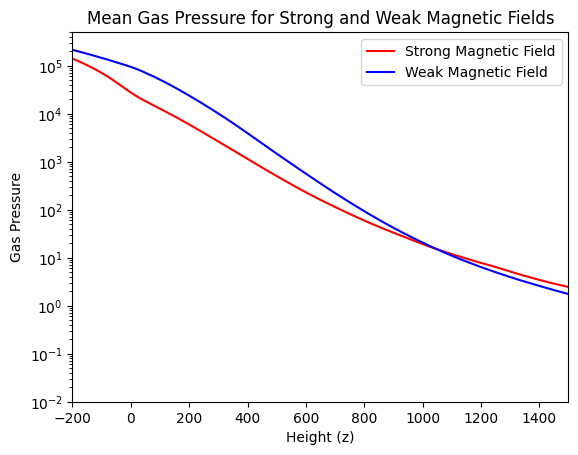

In [30]:
# Let's look also at the gas pressure:
plt.semilogy(z_axis, Pg_mean_strong, color='red', label='Strong Magnetic Field')
plt.semilogy(z_axis, Pg_mean_weak, color='blue', label='Weak Magnetic Field')
plt.xlabel('Height (z)')
plt.ylabel('Gas Pressure')
plt.xlim([-200,1500])
plt.ylim([1e-2, 5e5])
plt.title('Mean Gas Pressure for Strong and Weak Magnetic Fields')
plt.legend()
plt.savefig('figs_O_Steiner/mean_gas_pressure.png', bbox_inches='tight')


In [31]:
# Mean magnetic field for strong and weak magnetic regions
Bz_mean_strong = np.abs(Bz[strong_mask]).mean(axis=0)
Bz_mean_weak = np.abs(Bz[weak_mask]).mean(axis=0)

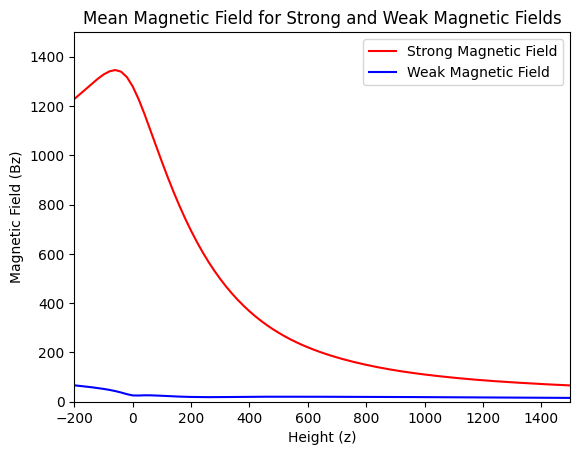

In [32]:
# Let's look also at the gas pressure:
plt.plot(z_axis, Bz_mean_strong, color='red', label='Strong Magnetic Field')
plt.plot(z_axis, Bz_mean_weak, color='blue', label='Weak Magnetic Field')
plt.xlabel('Height (z)')
plt.ylabel('Magnetic Field (Bz)')
plt.xlim([-200,1500])
plt.ylim([0, 1500])
plt.title('Mean Magnetic Field for Strong and Weak Magnetic Fields')
plt.legend()
plt.savefig('figs_O_Steiner/mean_magnetic_field.png', bbox_inches='tight')